Option 4: CNN work

In [107]:
import numpy as np
import torch
from torch import nn
import tqdm
import torchvision
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
import seaborn as sns
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import time
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [108]:
train_dataset = torchvision.datasets.FashionMNIST('data/', train=True, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ]))

test_dataset = torchvision.datasets.FashionMNIST('data/', train=False, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ]))


# Use the following code to create a validation set of 10%
train_indices, val_indices, _, _ = train_test_split(
    range(len(train_dataset)),
    train_dataset.targets,
    stratify=train_dataset.targets,
    test_size=0.1,
)

# Generate training and validation subsets based on indices
train_split = Subset(train_dataset, train_indices)
val_split = Subset(train_dataset, val_indices)


# set batches sizes
train_batch_size = 512 #Define train batch size
test_batch_size  = 256 #Define test batch size (can be larger than train batch size)


# Define dataloader objects that help to iterate over batches and samples for
# training, validation and testing
train_batches = DataLoader(train_split, batch_size=train_batch_size, shuffle=True)
val_batches = DataLoader(val_split, batch_size=train_batch_size, shuffle=True)
test_batches = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=True)
                                           
num_train_batches=len(train_batches)
num_val_batches=len(val_batches)
num_test_batches=len(test_batches)

In [109]:
def FCN_tr_and_eval(model, train_batches, val_batches, test_batches, epochs=40, lr=0.001):
    model.to(device)
    loss_func = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    tr_loss_list = np.zeros((epochs,))
    val_acc_list = np.zeros((epochs,))
    total_steps = epochs * len(train_batches)
    prog_bar = tqdm.tqdm(total=total_steps, position=0, desc=f"Training LR={lr}", leave=True)
    
    for epoch in range(epochs):
        running_loss = 0.0
        model.train()
        
        for train_features, train_labels in train_batches:
            train_features, train_labels = train_features.view(-1, 28*28).to(device), train_labels.to(device)
            optimizer.zero_grad()
            tr_outputs = model(train_features)
            loss = loss_func(tr_outputs, train_labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            prog_bar.update(1)
        
        tr_loss_list[epoch] = running_loss / len(train_batches)
        
        with torch.no_grad():
            model.eval()
            val_acc = []
            for val_features, val_labels in val_batches:
                val_features, val_labels = val_features.view(-1, 28*28).to(device), val_labels.to(device)
                val_outputs = model(val_features)
                correct = (torch.argmax(val_outputs, dim=1) == val_labels).type(torch.FloatTensor)
                val_acc.append(correct.mean().item())
            
            val_acc_list[epoch] = np.mean(val_acc) * 100 
        
        prog_bar.set_description(f"FCN| Epoch {epoch+1}/{epochs} | Train Loss: {tr_loss_list[epoch]:.4f} | Val Acc: {val_acc_list[epoch]:.2f}%")
    prog_bar.close()
    return tr_loss_list, val_acc_list

In [110]:
def CNN_tr_and_eval(model, train_batches, val_batches, test_batches, epochs = 40, lr=0.001):
    model.to(device)
    loss_func = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    tr_loss_list = np.zeros((epochs,))
    val_acc_list = np.zeros((epochs,))
    total_steps = epochs * len(train_batches)
    prog_bar = tqdm.tqdm(total=total_steps, position=0, desc=f"Training LR={lr}", leave=True)
    
    for epoch in range(epochs):
        running_loss = 0.0
        model.train()
        
        for train_features, train_labels in train_batches:
            train_features, train_labels = train_features.to(device), train_labels.to(device)
            optimizer.zero_grad()
            tr_outputs = model(train_features)
            loss = loss_func(tr_outputs, train_labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            prog_bar.update(1)
        
        tr_loss_list[epoch] = running_loss / len(train_batches)
        
        with torch.no_grad():
            model.eval()
            val_acc = []
            for val_features, val_labels in val_batches:
                val_features, val_labels = val_features.to(device), val_labels.to(device)
                val_outputs = model(val_features)
                correct = (torch.argmax(val_outputs, dim=1) == val_labels).type(torch.FloatTensor)
                val_acc.append(correct.mean().item())
            
            val_acc_list[epoch] = np.mean(val_acc) * 100 
        
        prog_bar.set_description(f"CNN | Epoch {epoch+1}/{epochs} | Train Loss: {tr_loss_list[epoch]:.4f} | Val Acc: {val_acc_list[epoch]:.2f}%")
    prog_bar.close()
    return tr_loss_list, val_acc_list

In [111]:
import torch
import torch.nn as nn

class FCN(nn.Module):
    def __init__(self, in_dim, out_dim, hid_layers, activation): 
        super(FCN, self).__init__()
        layers = []
        prev_dim = in_dim

        for hid_dim in hid_layers:
            layers.append(nn.Linear(prev_dim, hid_dim))
            layers.append(activation())
            prev_dim = hid_dim
        
        layers.append(nn.Linear(prev_dim, out_dim))
        self.model = nn.Sequential(*layers)

    def forward(self, input):
        return self.model(input)

Check Model is under 100k weights and that achieves 88 percent test accuracy

In [112]:
model = FCN(in_dim=784, hid_layers=[110, 110], out_dim=10, activation=nn.ReLU)
num_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {num_params}")

Total Parameters: 99670


In [113]:
runs = 5
epochs = 40
lr=0.001
ov_test_acc = []
tr_losses = []
all_val_acc = []
tr_time = []

# FCN 100K
for run in range(runs):
    print(f"Run {run+1}/{runs}")
    model = FCN(in_dim=784, hid_layers=[110, 110], out_dim=10, activation=nn.ReLU)
    
    s_time = time.time() 

    tr_loss_list, val_acc_list = FCN_tr_and_eval(model, train_batches, val_batches, test_batches, epochs)
    
    e_time = time.time() 
    tot_time = e_time - s_time
    tr_time.append(tot_time) 

    print(f"Training time for Run {run+1}: {tot_time:.2f} seconds")

    tr_losses.append(tr_loss_list)
    all_val_acc.append(val_acc_list)
    
    num_correct = 0
    total_samples = 0
    with torch.no_grad():
        model.eval()
        for test_features, test_labels in test_batches:
            test_features, test_labels = test_features.view(-1, 28*28).to(device), test_labels.to(device)
            test_outputs = model(test_features)
            predicted = torch.argmax(test_outputs, dim=1)
            correct = (predicted == test_labels).sum().item()
            total_samples += test_labels.size(0)
            num_correct += correct
    
    test_accuracy = (num_correct / total_samples) * 100
    ov_test_acc.append(test_accuracy)
    print(f"Test Accuracy for Run {run+1}: {test_accuracy:.2f}%")

test_acc_mean = np.mean(ov_test_acc)
test_acc_std = np.std(ov_test_acc)
avg_time = np.mean(tr_time)  

print(f"FCN 100K Mean Test Accuracy after {runs} runs: {test_acc_mean:.2f}% ± {test_acc_std:.2f}%")
print(f"FCN 100K Average Training Time per Run: {avg_time:.2f} seconds")

avg_train_loss_F100 = np.mean(tr_losses, axis=0)
avg_val_accuracy_F100 = np.mean(all_val_acc, axis=0)


Run 1/5


FCN| Epoch 40/40 | Train Loss: 0.1050 | Val Acc: 89.33%: 100%|█| 4240/4240 [03:3


Training time for Run 1: 211.41 seconds
Test Accuracy for Run 1: 88.57%
Run 2/5


FCN| Epoch 40/40 | Train Loss: 0.1074 | Val Acc: 90.42%: 100%|█| 4240/4240 [03:2


Training time for Run 2: 208.79 seconds
Test Accuracy for Run 2: 89.01%
Run 3/5


...

Training time for Run 3: 208.05 seconds
Test Accuracy for Run 3: 88.68%
Run 4/5


FCN| Epoch 40/40 | Train Loss: 0.1091 | Val Acc: 89.21%: 100%|█| 4240/4240 [03:2


Training time for Run 4: 207.84 seconds
Test Accuracy for Run 4: 87.86%
Run 5/5


FCN| Epoch 40/40 | Train Loss: 0.1054 | Val Acc: 89.58%: 100%|█| 4240/4240 [03:2


Training time for Run 5: 208.33 seconds
Test Accuracy for Run 5: 88.50%
FCN 100K Mean Test Accuracy after 5 runs: 88.52% ± 0.38%
FCN 100K Average Training Time per Run: 208.88 seconds


Task 2: 50K FCN Model

In [114]:
model = FCN(in_dim=784, hid_layers=[58, 58], out_dim=10, activation=nn.ReLU)
num_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {num_params}")

Total Parameters: 49542


In [115]:
runs = 5
epochs = 40
ov_test_acc = []
tr_losses = []
all_val_acc = []
tr_time = []

# FCN 50K
for run in range(runs):
    print(f"Run {run+1}/{runs}")
    model = FCN(in_dim=784, hid_layers=[58, 58], out_dim=10, activation=nn.ReLU)
    
    s_time = time.time() 

    tr_loss_list, val_acc_list = FCN_tr_and_eval(model, train_batches, val_batches, test_batches, epochs)
    
    e_time = time.time() 
    tot_time = e_time - s_time
    tr_time.append(tot_time) 

    print(f"Training time for Run {run+1}: {tot_time:.2f} seconds")

    tr_losses.append(tr_loss_list)
    all_val_acc.append(val_acc_list)
    
    num_correct = 0
    total_samples = 0
    with torch.no_grad():
        model.eval()
        for test_features, test_labels in test_batches:
            test_features, test_labels = test_features.view(-1, 28*28).to(device), test_labels.to(device)
            test_outputs = model(test_features)
            predicted = torch.argmax(test_outputs, dim=1)
            correct = (predicted == test_labels).sum().item()
            total_samples += test_labels.size(0)
            num_correct += correct
    
    test_accuracy = (num_correct / total_samples) * 100
    ov_test_acc.append(test_accuracy)
    print(f"Test Accuracy for Run {run+1}: {test_accuracy:.2f}%")

test_acc_mean = np.mean(ov_test_acc)
test_acc_std = np.std(ov_test_acc)
avg_time = np.mean(tr_time)  

print(f"FCN 50K Mean Test Accuracy after {runs} runs: {test_acc_mean:.2f}% ± {test_acc_std:.2f}%")
print(f"FCN 50K Average Training Time per Run: {avg_time:.2f} seconds")

avg_train_loss_F50 = np.mean(tr_losses, axis=0)
avg_val_accuracy_F50 = np.mean(all_val_acc, axis=0)


Run 1/5


FCN| Epoch 40/40 | Train Loss: 0.1617 | Val Acc: 89.34%: 100%|█| 4240/4240 [03:2


Training time for Run 1: 201.94 seconds
Test Accuracy for Run 1: 87.66%
Run 2/5


FCN| Epoch 40/40 | Train Loss: 0.1660 | Val Acc: 88.88%: 100%|█| 4240/4240 [03:2


Training time for Run 2: 200.75 seconds
Test Accuracy for Run 2: 88.11%
Run 3/5


...

Training time for Run 3: 201.73 seconds
Test Accuracy for Run 3: 87.59%
Run 4/5


FCN| Epoch 40/40 | Train Loss: 0.1615 | Val Acc: 88.90%: 100%|█| 4240/4240 [03:2


Training time for Run 4: 201.45 seconds
Test Accuracy for Run 4: 88.16%
Run 5/5


FCN| Epoch 40/40 | Train Loss: 0.1696 | Val Acc: 89.01%: 100%|█| 4240/4240 [03:2


Training time for Run 5: 200.36 seconds
Test Accuracy for Run 5: 88.61%
FCN 50K Mean Test Accuracy after 5 runs: 88.03% ± 0.37%
FCN 50K Average Training Time per Run: 201.25 seconds


200K FCN Model Training and Testing with Runs

In [116]:
model = FCN(in_dim=784, hid_layers=[200, 200], out_dim=10, activation=nn.ReLU)
num_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {num_params}")

Total Parameters: 199210


In [117]:
runs = 5
epochs = 40
ov_test_acc = []
tr_losses = []
all_val_acc = []
tr_time = []

# FCN 200K
for run in range(runs):
    print(f"Run {run+1}/{runs}")
    model = FCN(in_dim=784, hid_layers=[200, 200], out_dim=10, activation=nn.ReLU)
    
    s_time = time.time() 

    tr_loss_list, val_acc_list = FCN_tr_and_eval(model, train_batches, val_batches, test_batches, epochs)
    
    e_time = time.time() 
    tot_time = e_time - s_time
    tr_time.append(tot_time) 

    print(f"Training time for Run {run+1}: {tot_time:.2f} seconds")

    tr_losses.append(tr_loss_list)
    all_val_acc.append(val_acc_list)
    
    num_correct = 0
    total_samples = 0
    with torch.no_grad():
        model.eval()
        for test_features, test_labels in test_batches:
            test_features, test_labels = test_features.view(-1, 28*28).to(device), test_labels.to(device)
            test_outputs = model(test_features)
            predicted = torch.argmax(test_outputs, dim=1)
            correct = (predicted == test_labels).sum().item()
            total_samples += test_labels.size(0)
            num_correct += correct
    
    test_accuracy = (num_correct / total_samples) * 100
    ov_test_acc.append(test_accuracy)
    print(f"Test Accuracy for Run {run+1}: {test_accuracy:.2f}%")

test_acc_mean = np.mean(ov_test_acc)
test_acc_std = np.std(ov_test_acc)
avg_time = np.mean(tr_time)  

print(f"FCN 200K Mean Test Accuracy after {runs} runs: {test_acc_mean:.2f}% ± {test_acc_std:.2f}%")
print(f"FCN 200K Average Training Time per Run: {avg_time:.2f} seconds")

avg_train_loss_F200 = np.mean(tr_losses, axis=0)
avg_val_accuracy_F200 = np.mean(all_val_acc, axis=0)


Run 1/5


FCN| Epoch 40/40 | Train Loss: 0.0700 | Val Acc: 89.46%: 100%|█| 4240/4240 [03:3


Training time for Run 1: 210.24 seconds
Test Accuracy for Run 1: 88.66%
Run 2/5


FCN| Epoch 40/40 | Train Loss: 0.0703 | Val Acc: 90.15%: 100%|█| 4240/4240 [03:2


Training time for Run 2: 209.53 seconds
Test Accuracy for Run 2: 89.03%
Run 3/5


...

Training time for Run 3: 209.33 seconds
Test Accuracy for Run 3: 88.53%
Run 4/5


FCN| Epoch 40/40 | Train Loss: 0.0695 | Val Acc: 89.03%: 100%|█| 4240/4240 [03:3


Training time for Run 4: 210.22 seconds
Test Accuracy for Run 4: 88.22%
Run 5/5


FCN| Epoch 40/40 | Train Loss: 0.0700 | Val Acc: 89.67%: 100%|█| 4240/4240 [03:3


Training time for Run 5: 210.30 seconds
Test Accuracy for Run 5: 88.99%
FCN 200K Mean Test Accuracy after 5 runs: 88.69% ± 0.30%
FCN 200K Average Training Time per Run: 209.93 seconds


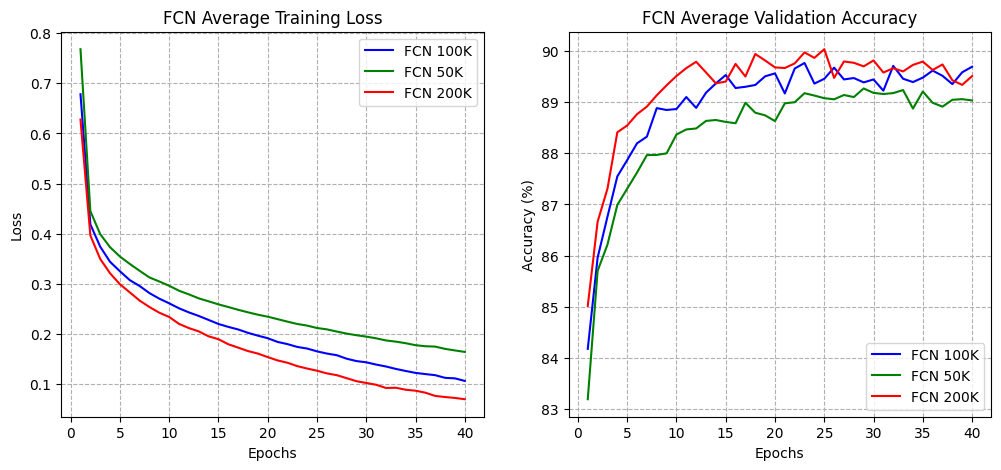

In [118]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(range(1, epochs+1), avg_train_loss_F100, label='FCN 100K', color='b')
ax[0].plot(range(1, epochs+1), avg_train_loss_F50, label='FCN 50K', color='g')
ax[0].plot(range(1, epochs+1), avg_train_loss_F200, label='FCN 200K', color='r')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('FCN Average Training Loss')
ax[0].legend()
ax[0].grid(True, linestyle='--')
ax[1].plot(range(1, epochs+1), avg_val_accuracy_F100, label='FCN 100K', color='b')
ax[1].plot(range(1, epochs+1), avg_val_accuracy_F50, label='FCN 50K', color='g')
ax[1].plot(range(1, epochs+1), avg_val_accuracy_F200, label='FCN 200K', color='r')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title('FCN Average Validation Accuracy')
ax[1].legend()
ax[1].grid(True, linestyle='--')
plt.savefig('FCN_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Creating CNN 100K

In [119]:
class CNN_100K(nn.Module):
    def __init__(self):
        super(CNN_100K, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)  
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 7 * 7, 25)  
        self.fc2 = nn.Linear(25, 10)      

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1) 
        x = F.relu(self.fc1(x))  
        x = self.fc2(x) 
        return x

In [120]:
model = CNN_100K()
num_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {num_params}")

Total Parameters: 97501


In [121]:
runs = 5
epochs = 40
ov_test_acc = []
tr_losses = []
all_val_acc = []
tr_time = []

# CNN 100K
for run in range(runs):
    print(f"Run {run+1}/{runs}")
    model = CNN_100K()
    
    s_time = time.time() 

    tr_loss_list, val_acc_list = CNN_tr_and_eval(model, train_batches, val_batches, test_batches, epochs)
    
    e_time = time.time() 
    tot_time = e_time - s_time
    tr_time.append(tot_time) 

    print(f"Training time for Run {run+1}: {tot_time:.2f} seconds")

    tr_losses.append(tr_loss_list)
    all_val_acc.append(val_acc_list)
    
    num_correct = 0
    total_samples = 0
    with torch.no_grad():
        model.eval()
        for test_features, test_labels in test_batches:
            test_features, test_labels = test_features.to(device), test_labels.to(device)
            test_outputs = model(test_features)
            predicted = torch.argmax(test_outputs, dim=1)
            correct = (predicted == test_labels).sum().item()
            total_samples += test_labels.size(0)
            num_correct += correct
    
    test_accuracy = (num_correct / total_samples) * 100
    ov_test_acc.append(test_accuracy)
    print(f"Test Accuracy for Run {run+1}: {test_accuracy:.2f}%")

test_acc_mean = np.mean(ov_test_acc)
test_acc_std = np.std(ov_test_acc)
avg_time = np.mean(tr_time)  

print(f"CNN 100K Mean Test Accuracy after {runs} runs: {test_acc_mean:.2f}% ± {test_acc_std:.2f}%")
print(f"CNN 100K Average Training Time per Run: {avg_time:.2f} seconds")

avg_train_loss_C100 = np.mean(tr_losses, axis=0)
avg_val_accuracy_C100 = np.mean(all_val_acc, axis=0)

Run 1/5


CNN | Epoch 40/40 | Train Loss: 0.0824 | Val Acc: 92.39%: 100%|█| 4240/4240 [21:


Training time for Run 1: 1299.10 seconds
Test Accuracy for Run 1: 91.68%
Run 2/5


CNN | Epoch 40/40 | Train Loss: 0.0942 | Val Acc: 92.03%: 100%|█| 4240/4240 [21:


Training time for Run 2: 1301.12 seconds
Test Accuracy for Run 2: 91.22%
Run 3/5


...

Training time for Run 3: 1299.00 seconds
Test Accuracy for Run 3: 91.25%
Run 4/5


CNN | Epoch 40/40 | Train Loss: 0.0798 | Val Acc: 90.89%: 100%|█| 4240/4240 [21:


Training time for Run 4: 1298.94 seconds
Test Accuracy for Run 4: 90.46%
Run 5/5


CNN | Epoch 40/40 | Train Loss: 0.0885 | Val Acc: 92.96%: 100%|█| 4240/4240 [21:


Training time for Run 5: 1296.81 seconds
Test Accuracy for Run 5: 91.54%
CNN 100K Mean Test Accuracy after 5 runs: 91.23% ± 0.42%
CNN 100K Average Training Time per Run: 1298.99 seconds


CNN 50K

In [122]:
class CNN_50K(nn.Module):
    def __init__(self):
        super(CNN_50K, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1) 
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  

        self.fc1 = nn.Linear(32 * 7 * 7, 25)  
        self.fc2 = nn.Linear(25, 10) 

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  
        x = self.pool(F.relu(self.conv2(x)))  
        x = x.view(x.size(0), -1)   
        x = F.relu(self.fc1(x))  
        x = self.fc2(x) 
        return x

In [123]:
model = CNN_50K()
num_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {num_params}")

Total Parameters: 44285


In [124]:
runs = 5
epochs = 40
ov_test_acc = []
tr_losses = []
all_val_acc = []
tr_time = []

# CNN 50K
for run in range(runs):
    print(f"Run {run+1}/{runs}")
    model = CNN_50K()
    
    s_time = time.time() 

    tr_loss_list, val_acc_list = CNN_tr_and_eval(model, train_batches, val_batches, test_batches, epochs)
    
    e_time = time.time() 
    tot_time = e_time - s_time
    tr_time.append(tot_time) 

    print(f"Training time for Run {run+1}: {tot_time:.2f} seconds")

    tr_losses.append(tr_loss_list)
    all_val_acc.append(val_acc_list)
    
    num_correct = 0
    total_samples = 0
    with torch.no_grad():
        model.eval()
        for test_features, test_labels in test_batches:
            test_features, test_labels = test_features.to(device), test_labels.to(device)
            test_outputs = model(test_features)
            predicted = torch.argmax(test_outputs, dim=1)
            correct = (predicted == test_labels).sum().item()
            total_samples += test_labels.size(0)
            num_correct += correct
    
    test_accuracy = (num_correct / total_samples) * 100
    ov_test_acc.append(test_accuracy)
    print(f"Test Accuracy for Run {run+1}: {test_accuracy:.2f}%")

test_acc_mean = np.mean(ov_test_acc)
test_acc_std = np.std(ov_test_acc)
avg_time = np.mean(tr_time)  

print(f"CNN 50K Mean Test Accuracy after {runs} runs: {test_acc_mean:.2f}% ± {test_acc_std:.2f}%")
print(f"CNN 50K Average Training Time per Run: {avg_time:.2f} seconds")

avg_train_loss_C50 = np.mean(tr_losses, axis=0)
avg_val_accuracy_C50 = np.mean(all_val_acc, axis=0)

Run 1/5


CNN | Epoch 40/40 | Train Loss: 0.1448 | Val Acc: 92.04%: 100%|█| 4240/4240 [12:


Training time for Run 1: 762.34 seconds
Test Accuracy for Run 1: 91.18%
Run 2/5


CNN | Epoch 40/40 | Train Loss: 0.1701 | Val Acc: 91.87%: 100%|█| 4240/4240 [12:


Training time for Run 2: 761.31 seconds
Test Accuracy for Run 2: 91.04%
Run 3/5


...

Training time for Run 3: 761.70 seconds
Test Accuracy for Run 3: 90.54%
Run 4/5


CNN | Epoch 40/40 | Train Loss: 0.1590 | Val Acc: 91.51%: 100%|█| 4240/4240 [12:


Training time for Run 4: 760.73 seconds
Test Accuracy for Run 4: 91.01%
Run 5/5


CNN | Epoch 40/40 | Train Loss: 0.1618 | Val Acc: 91.83%: 100%|█| 4240/4240 [12:


Training time for Run 5: 759.81 seconds
Test Accuracy for Run 5: 90.81%
CNN 50K Mean Test Accuracy after 5 runs: 90.92% ± 0.22%
CNN 50K Average Training Time per Run: 761.18 seconds


CNN_20K

In [125]:
class CNN_20K(nn.Module):
    def __init__(self):
        super(CNN_20K, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1) 
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) 

        self.fc1 = nn.Linear(16 * 7 * 7, 25)  
        self.fc2 = nn.Linear(25, 10)  

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  
        x = self.pool(F.relu(self.conv2(x)))  
        x = x.view(x.size(0), -1)   
        x = F.relu(self.fc1(x))  
        x = self.fc2(x) 
        return x

In [126]:
model = CNN_20K()
num_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {num_params}")

Total Parameters: 21133


In [127]:
runs = 5
epochs = 40
ov_test_acc = []
tr_losses = []
all_val_acc = []
tr_time = []

# CNN 20K
for run in range(runs):
    print(f"Run {run+1}/{runs}")
    model = CNN_20K()
    
    s_time = time.time() 

    tr_loss_list, val_acc_list = CNN_tr_and_eval(model, train_batches, val_batches, test_batches, epochs)
    
    e_time = time.time() 
    tot_time = e_time - s_time
    tr_time.append(tot_time) 

    print(f"Training time for Run {run+1}: {tot_time:.2f} seconds")

    tr_losses.append(tr_loss_list)
    all_val_acc.append(val_acc_list)
    
    num_correct = 0
    total_samples = 0
    with torch.no_grad():
        model.eval()
        for test_features, test_labels in test_batches:
            test_features, test_labels = test_features.to(device), test_labels.to(device)
            test_outputs = model(test_features)
            predicted = torch.argmax(test_outputs, dim=1)
            correct = (predicted == test_labels).sum().item()
            total_samples += test_labels.size(0)
            num_correct += correct
    
    test_accuracy = (num_correct / total_samples) * 100
    ov_test_acc.append(test_accuracy)
    print(f"Test Accuracy for Run {run+1}: {test_accuracy:.2f}%")

test_acc_mean = np.mean(ov_test_acc)
test_acc_std = np.std(ov_test_acc)
avg_time = np.mean(tr_time)  

print(f"CNN 20K Mean Test Accuracy after {runs} runs: {test_acc_mean:.2f}% ± {test_acc_std:.2f}%")
print(f"CNN 20K Average Training Time per Run: {avg_time:.2f} seconds")

avg_train_loss_C20 = np.mean(tr_losses, axis=0)
avg_val_accuracy_C20 = np.mean(all_val_acc, axis=0)

Run 1/5


CNN | Epoch 40/40 | Train Loss: 0.2187 | Val Acc: 90.90%: 100%|█| 4240/4240 [08:


Training time for Run 1: 518.72 seconds
Test Accuracy for Run 1: 89.65%
Run 2/5


CNN | Epoch 40/40 | Train Loss: 0.2258 | Val Acc: 91.13%: 100%|█| 4240/4240 [08:


Training time for Run 2: 518.61 seconds
Test Accuracy for Run 2: 89.88%
Run 3/5


...

Training time for Run 3: 515.53 seconds
Test Accuracy for Run 3: 90.36%
Run 4/5


CNN | Epoch 40/40 | Train Loss: 0.2080 | Val Acc: 90.25%: 100%|█| 4240/4240 [08:


Training time for Run 4: 517.53 seconds
Test Accuracy for Run 4: 89.23%
Run 5/5


CNN | Epoch 40/40 | Train Loss: 0.2117 | Val Acc: 90.66%: 100%|█| 4240/4240 [08:


Training time for Run 5: 516.86 seconds
Test Accuracy for Run 5: 90.16%
CNN 20K Mean Test Accuracy after 5 runs: 89.86% ± 0.40%
CNN 20K Average Training Time per Run: 517.45 seconds


In [128]:
class CNN_10K(nn.Module):
    def __init__(self):
        super(CNN_10K, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=4, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=4, out_channels=8, kernel_size=3, padding=1) 
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) 

        self.fc1 = nn.Linear(8 * 7 * 7, 25)  
        self.fc2 = nn.Linear(25, 10)  

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  
        x = self.pool(F.relu(self.conv2(x)))  
        x = x.view(x.size(0), -1)   
        x = F.relu(self.fc1(x))  
        x = self.fc2(x) 
        return x

In [129]:
model = CNN_10K()
num_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {num_params}")

Total Parameters: 10421


In [130]:
runs = 5
epochs = 40
ov_test_acc = []
tr_losses = []
all_val_acc = []
tr_time = []

# CNN 10K
for run in range(runs):
    print(f"Run {run+1}/{runs}")
    model = CNN_10K()
    
    s_time = time.time() 

    tr_loss_list, val_acc_list = CNN_tr_and_eval(model, train_batches, val_batches, test_batches, epochs)
    
    e_time = time.time() 
    tot_time = e_time - s_time
    tr_time.append(tot_time) 

    print(f"Training time for Run {run+1}: {tot_time:.2f} seconds")

    tr_losses.append(tr_loss_list)
    all_val_acc.append(val_acc_list)
    
    num_correct = 0
    total_samples = 0
    with torch.no_grad():
        model.eval()
        for test_features, test_labels in test_batches:
            test_features, test_labels = test_features.to(device), test_labels.to(device)
            test_outputs = model(test_features)
            predicted = torch.argmax(test_outputs, dim=1)
            correct = (predicted == test_labels).sum().item()
            total_samples += test_labels.size(0)
            num_correct += correct
    
    test_accuracy = (num_correct / total_samples) * 100
    ov_test_acc.append(test_accuracy)
    print(f"Test Accuracy for Run {run+1}: {test_accuracy:.2f}%")

test_acc_mean = np.mean(ov_test_acc)
test_acc_std = np.std(ov_test_acc)
avg_time = np.mean(tr_time)  

print(f"CNN 10K Mean Test Accuracy after {runs} runs: {test_acc_mean:.2f}% ± {test_acc_std:.2f}%")
print(f"CNN 10K Average Training Time per Run: {avg_time:.2f} seconds")

avg_train_loss_C10 = np.mean(tr_losses, axis=0)
avg_val_accuracy_C10 = np.mean(all_val_acc, axis=0)

Run 1/5


CNN | Epoch 40/40 | Train Loss: 0.2607 | Val Acc: 89.87%: 100%|█| 4240/4240 [06:


Training time for Run 1: 388.29 seconds
Test Accuracy for Run 1: 88.60%
Run 2/5


CNN | Epoch 40/40 | Train Loss: 0.2642 | Val Acc: 89.89%: 100%|█| 4240/4240 [06:


Training time for Run 2: 387.17 seconds
Test Accuracy for Run 2: 88.99%
Run 3/5


...

Training time for Run 3: 389.99 seconds
Test Accuracy for Run 3: 88.18%
Run 4/5


CNN | Epoch 40/40 | Train Loss: 0.2758 | Val Acc: 89.76%: 100%|█| 4240/4240 [06:


Training time for Run 4: 388.38 seconds
Test Accuracy for Run 4: 88.48%
Run 5/5


CNN | Epoch 40/40 | Train Loss: 0.2864 | Val Acc: 89.63%: 100%|█| 4240/4240 [06:


Training time for Run 5: 388.74 seconds
Test Accuracy for Run 5: 88.45%
CNN 10K Mean Test Accuracy after 5 runs: 88.54% ± 0.26%
CNN 10K Average Training Time per Run: 388.51 seconds


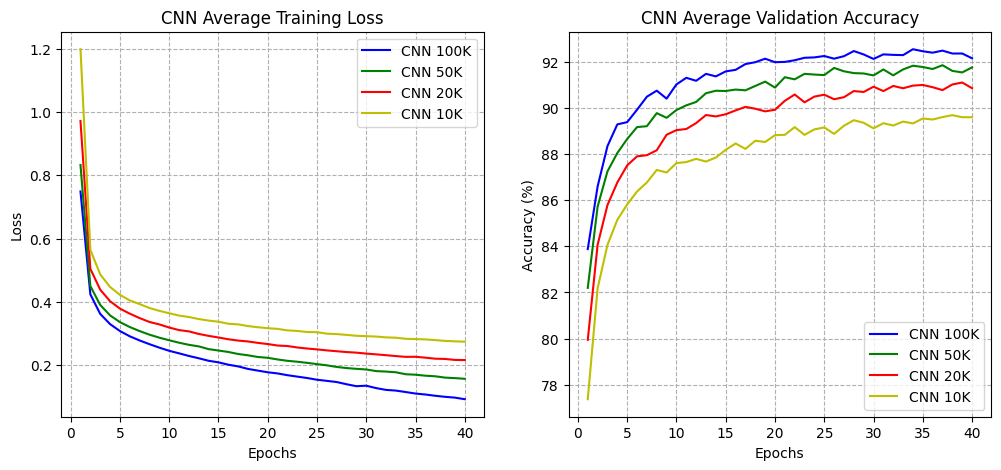

In [131]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(range(1, epochs+1), avg_train_loss_C100, label='CNN 100K', color='b')
ax[0].plot(range(1, epochs+1), avg_train_loss_C50, label='CNN 50K', color='g')
ax[0].plot(range(1, epochs+1), avg_train_loss_C20, label= 'CNN 20K', color='r')
ax[0].plot(range(1, epochs+1), avg_train_loss_C10, label= 'CNN 10K', color='y')

ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('CNN Average Training Loss')
ax[0].legend()
ax[0].grid(True, linestyle='--')

ax[1].plot(range(1, epochs+1), avg_val_accuracy_C100, label='CNN 100K', color='b')
ax[1].plot(range(1, epochs+1), avg_val_accuracy_C50, label='CNN 50K', color='g')
ax[1].plot(range(1, epochs+1), avg_val_accuracy_C20, label= 'CNN 20K', color='r')
ax[1].plot(range(1, epochs+1), avg_val_accuracy_C10, label= 'CNN 10K', color='y')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title('CNN Average Validation Accuracy')
ax[1].legend()
ax[1].grid(True, linestyle='--')
plt.savefig('CNN_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()